### Feature selection 


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('Algerian_forest_fires_Cleaned_dataset.csv')
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [4]:
## Droping Month, Day ,year Features

df.drop(['day','month','year'],axis=1,inplace=True)

In [5]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [6]:
## Encoding 
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [7]:
df['Classes']=np.where(df['Classes'].str.contains('not fire'),0,1)
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [8]:
## Independent and Dependent Features

X=df.drop('FWI',axis=1)
y=df['FWI']


In [9]:
## Train test split

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [10]:
X_train.shape,X_test.shape

((182, 11), (61, 11))

<Axes: >

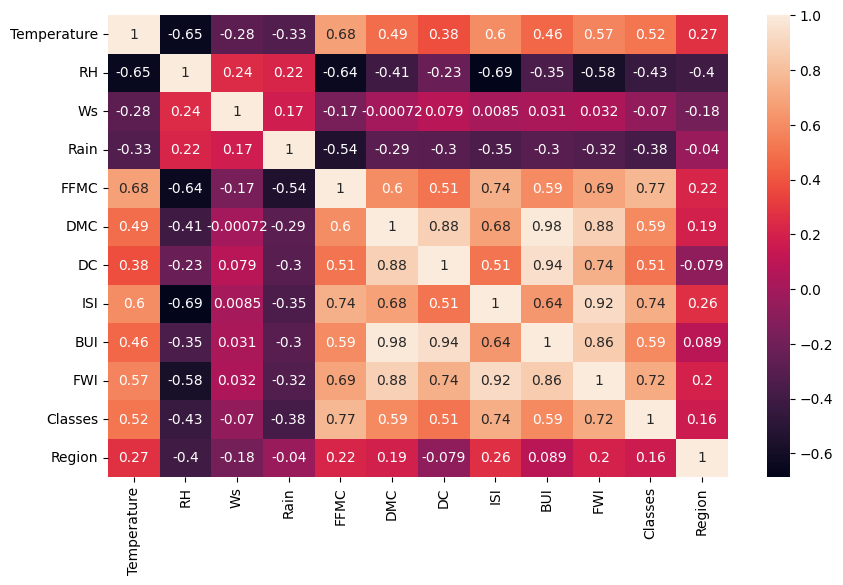

In [11]:
## Check for Multicollinearity

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True)

In [12]:
def correlation(dataset,thresold):
    col_corr=set()
    cor_matrix=dataset.corr()
    for i in range(len(cor_matrix.columns)):
        for j in range(i):
            if abs(cor_matrix.iloc[i,j])>thresold:
                colname=cor_matrix.columns[i]
                col_corr.add(colname)
                
    return col_corr
            
    

In [13]:
## Threshold value is set by Expects
corr_features=correlation(X_train,0.85)
corr_features

{'BUI', 'DC'}

In [14]:
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)

X_train.shape,X_test.shape

((182, 9), (61, 9))

In [15]:
## Feature Scaling and  StandardScaler

from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)



In [56]:
X_train

,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,Classes,Region
97,29,74,19,0.1,75.8,3.6,2.1,0,0
141,31,72,14,0.2,60.2,3.8,0.8,0,1
192,40,31,15,0.0,94.2,22.5,16.6,1,1
68,32,60,18,0.3,77.1,11.3,2.2,0,0
119,32,47,14,0.7,77.5,7.1,1.8,0,0
...,...,...,...,...,...,...,...,...,...
106,24,82,15,0.4,44.9,0.9,0.2,0,0
14,28,80,17,3.1,49.4,3.0,0.4,0,0
92,25,76,17,7.2,46.0,1.3,0.2,0,0
179,34,59,16,0.0,88.1,19.5,7.4,1,1


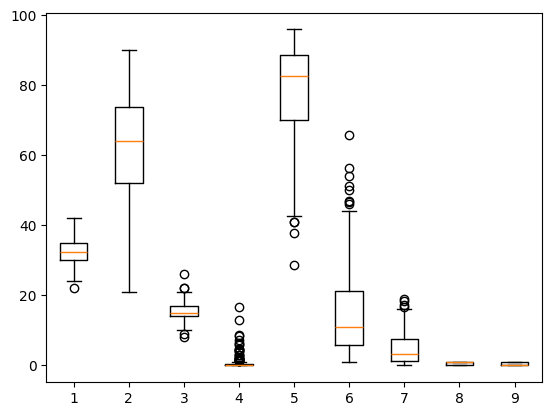

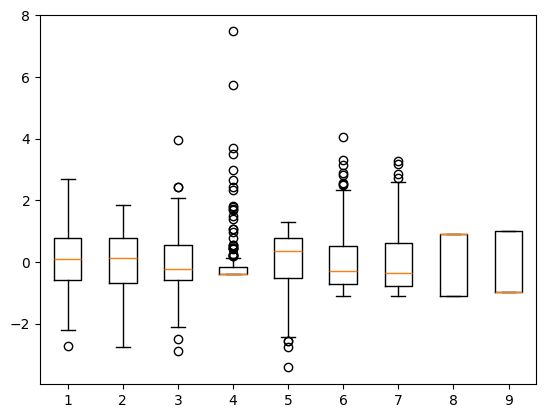

In [16]:
##Box Plot comparission between  X_train and X_train_scaled


plt.boxplot(X_train)
plt.show()
plt.boxplot(X_train_scaled)
plt.show()
 

## Model Training


### Linear Regression

In [51]:
X_train_scaled.shape

(182, 9)

mean_squared_error 0.674276687379158
mean_absolute_error: 0.5468236465249978
r2_score: 0.9847657384266951


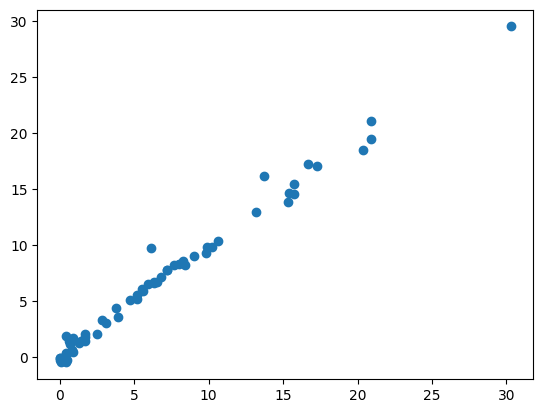

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

regression = LinearRegression()
regression.fit(X_train_scaled,y_train)

y_pred = regression.predict(X_test_scaled)

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r_score=r2_score(y_test,y_pred)
print("mean_squared_error",mse)
print("mean_absolute_error:",mae)
print("r2_score:",r_score)
plt.scatter(y_test,y_pred)





### Lasso Regression


mean_squared_error 2.248345891897476
mean_absolute_error: 1.1331759949144087
r2_score: 0.9492020263112388


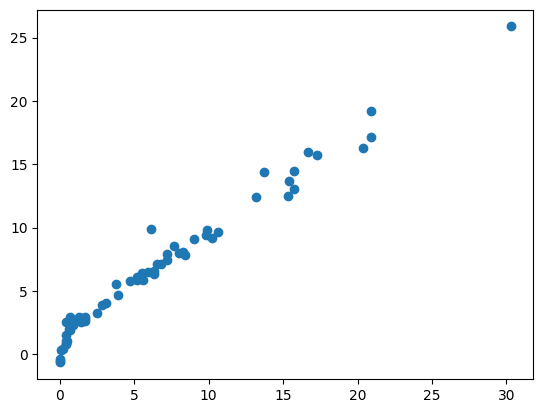

In [38]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

lasso = Lasso()
lasso.fit(X_train_scaled,y_train)

y_pred = lasso.predict(X_test_scaled)

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r_score=r2_score(y_test,y_pred)
print("mean_squared_error",mse)
print("mean_absolute_error:",mae)
print("r2_score:",r_score)
plt.scatter(y_test,y_pred)

### Lasso CV (Cross Validation)


mean_squared_error 0.8214458563350046
mean_absolute_error: 0.6358894638564663
r2_score: 0.9814406737205228


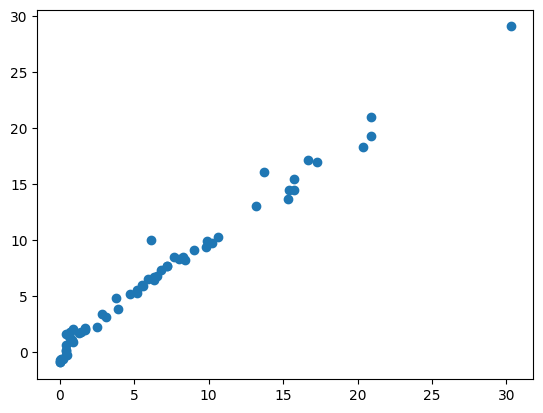

In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

lassocv = LassoCV()
lassocv.fit(X_train_scaled,y_train)

y_pred = lassocv.predict(X_test_scaled)

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r_score=r2_score(y_test,y_pred)
print("mean_squared_error",mse)
print("mean_absolute_error:",mae)
print("r2_score:",r_score)
plt.scatter(y_test,y_pred)

### Ridge Regression


mean_squared_error 0.6949198918152096
mean_absolute_error: 0.5642305340105715
r2_score: 0.9842993364555512


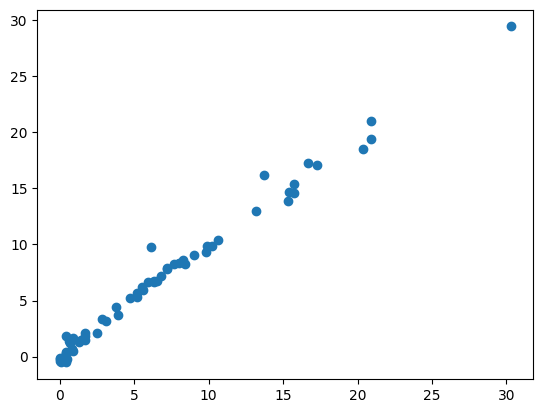

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

ridge = Ridge()
ridge.fit(X_train_scaled,y_train)

y_pred = ridge.predict(X_test_scaled)

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r_score=r2_score(y_test,y_pred)
print("mean_squared_error",mse)
print("mean_absolute_error:",mae)
print("r2_score:",r_score)
plt.scatter(y_test,y_pred)

### Ridge CV

mean_squared_error 0.6949198918151778
mean_absolute_error: 0.5642305340106404
r2_score: 0.984299336455552


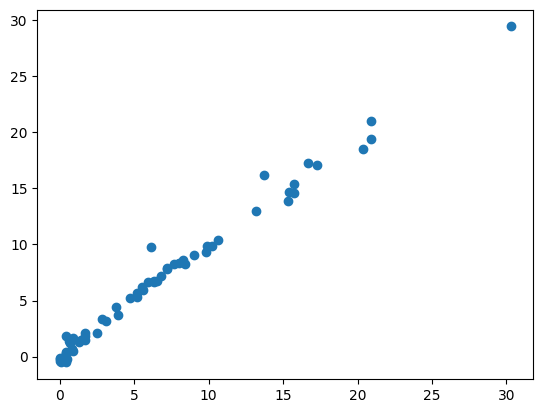

In [41]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

ridgecv = RidgeCV()
ridgecv.fit(X_train_scaled,y_train)

y_pred = ridgecv.predict(X_test_scaled)

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r_score=r2_score(y_test,y_pred)
print("mean_squared_error",mse)
print("mean_absolute_error:",mae)
print("r2_score:",r_score)
plt.scatter(y_test,y_pred)

### ElasticNet


mean_squared_error 5.517251101025223
mean_absolute_error: 1.8822353634895999
r2_score: 0.8753460589519703


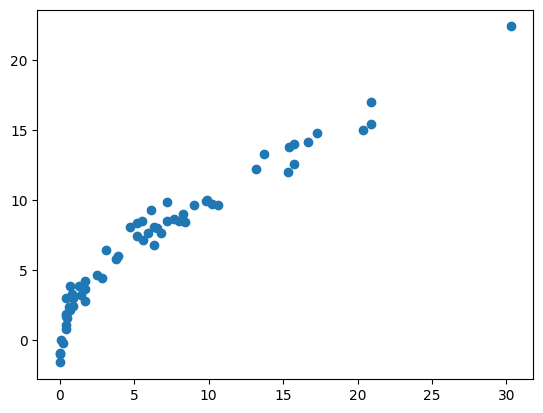

In [42]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

elasticnet = ElasticNet()
elasticnet.fit(X_train_scaled,y_train)

y_pred = elasticnet.predict(X_test_scaled)

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r_score=r2_score(y_test,y_pred)
print("mean_squared_error",mse)
print("mean_absolute_error:",mae)
print("r2_score:",r_score)
plt.scatter(y_test,y_pred)

### ElasticNet CV


mean_squared_error 0.8222830416276266
mean_absolute_error: 0.6575946731430901
r2_score: 0.9814217587854941


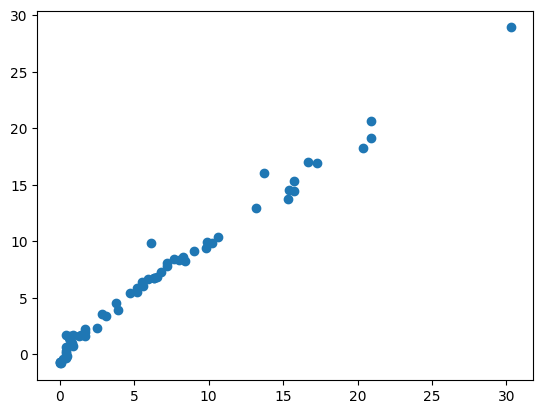

In [43]:
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

elasticnetcv = ElasticNetCV()
elasticnetcv.fit(X_train_scaled,y_train)

y_pred = elasticnetcv.predict(X_test_scaled)

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r_score=r2_score(y_test,y_pred)
print("mean_squared_error",mse)
print("mean_absolute_error:",mae)
print("r2_score:",r_score)
plt.scatter(y_test,y_pred)

### Pickle
python pickle module is serializing and de-serialixing a python object  structure. Any object in python can be pickled so that it can be saved on disk

In [44]:
import pickle
pickle.dump(ridge,open('ridge_mode.pkl','wb'))
pickle.dump(scaler,open('scaler.pkl','wb'))

In [46]:
model=pickle.load(open('ridge_mode.pkl','rb'))
std_scaler=pickle.load(open('scaler.pkl','rb'))

In [52]:
scaled=std_scaler.transform([[29,57,18,0.0,	65.7,3.4,7.6,0,0]])
print(model.predict(scaled))

[7.59060148]


c:\Users\ARASU\OneDrive\Desktop\python\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [57]:
scaled=scaler.transform([[29,74,19,0.1,75.8,3.6,2.1,0,1]])
print(ridge.predict(scaled))

[0.05865138]


c:\Users\ARASU\OneDrive\Desktop\python\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
